# TPC-DS Feature-Space Analysis

Computes the 5-dimensional matching feature table for all 297 TPC-DS
(template, query_index) pairs, visualises the feature space, and persists
the feature table for downstream use by the Redset mapper.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

import autoslo.utils.paths as pu
from autoslo.featurization.tpcds_matching_featurizer import TpcdsMatchingFeaturizer

In [ ]:
run_id = pu.RunLocator.get_run_ids(
    workload_name="benchmarking_workload_99_3_3_shuffled_42",
)[-1]

In [3]:
# ── Featurize all 297 pairs ──

featurizer = TpcdsMatchingFeaturizer()
feature_df = featurizer.featurize_traces([run_id])

print(f"{len(feature_df)} unique (template, q_idx) pairs featurized.")
feature_df.head(10)

  [1/1] 1767009691
297 unique (template, q_idx) pairs featurized.


,num_joins,num_scans,num_aggregations,num_permanent_tables_accessed,log_mbytes_scanned
tpcds_temp_and_q_idx,,,,,
001_001,6.0,11.0,3.0,6.0,8.047421
001_002,6.0,11.0,3.0,6.0,8.614359
001_003,6.0,11.0,3.0,6.0,8.576355
002_001,4.0,9.0,1.0,5.0,11.101810
002_002,4.0,9.0,1.0,5.0,11.101810
002_003,4.0,9.0,1.0,5.0,11.101810
003_001,2.0,3.0,1.0,3.0,1.712699
003_002,2.0,3.0,1.0,3.0,1.724366
003_003,2.0,3.0,1.0,3.0,1.641538


In [4]:
stats_df = featurizer.compute_normalization_stats(feature_df)
stats_df

,num_joins,num_scans,num_aggregations,num_permanent_tables_accessed,log_mbytes_scanned
mean,6.696970,11.171717,2.535354,8.272727,7.454686
std,5.431616,8.960545,2.772865,5.828318,2.886642


In [5]:
normalized_feature_df = featurizer.normalize(feature_df, stats_df)
normalized_feature_df.head(10)

,num_joins,num_scans,num_aggregations,num_permanent_tables_accessed,log_mbytes_scanned
tpcds_temp_and_q_idx,,,,,
001_001,-0.128317,-0.019164,0.167569,-0.389946,0.205337
001_002,-0.128317,-0.019164,0.167569,-0.389946,0.401738
001_003,-0.128317,-0.019164,0.167569,-0.389946,0.388572
002_001,-0.496532,-0.242364,-0.553707,-0.561522,1.263449
002_002,-0.496532,-0.242364,-0.553707,-0.561522,1.263449
002_003,-0.496532,-0.242364,-0.553707,-0.561522,1.263449
003_001,-0.864746,-0.911967,-0.553707,-0.904674,-1.989158
003_002,-0.864746,-0.911967,-0.553707,-0.904674,-1.985117
003_003,-0.864746,-0.911967,-0.553707,-0.904674,-2.013810


In [16]:
whitened_feature_df = featurizer.whiten(feature_df, stats_df)
whitened_feature_df.head(10)

,num_joins,num_scans,num_aggregations,num_permanent_tables_accessed,log_mbytes_scanned
tpcds_temp_and_q_idx,,,,,
001_001,0.267449,0.364377,0.244712,-1.088684,0.211565
001_002,0.257323,0.344126,0.213024,-1.091856,0.425539
001_003,0.258001,0.345484,0.215148,-1.091643,0.411195
002_001,-0.645506,0.715968,-0.937116,-0.760860,1.525498
002_002,-0.645506,0.715968,-0.937116,-0.760860,1.525498
002_003,-0.645506,0.715968,-0.937116,-0.760860,1.525498
003_001,-0.350820,-0.422354,0.081907,-0.495829,-1.924575
003_002,-0.351028,-0.422771,0.081255,-0.495894,-1.920172
003_003,-0.349549,-0.419813,0.085884,-0.495431,-1.951433


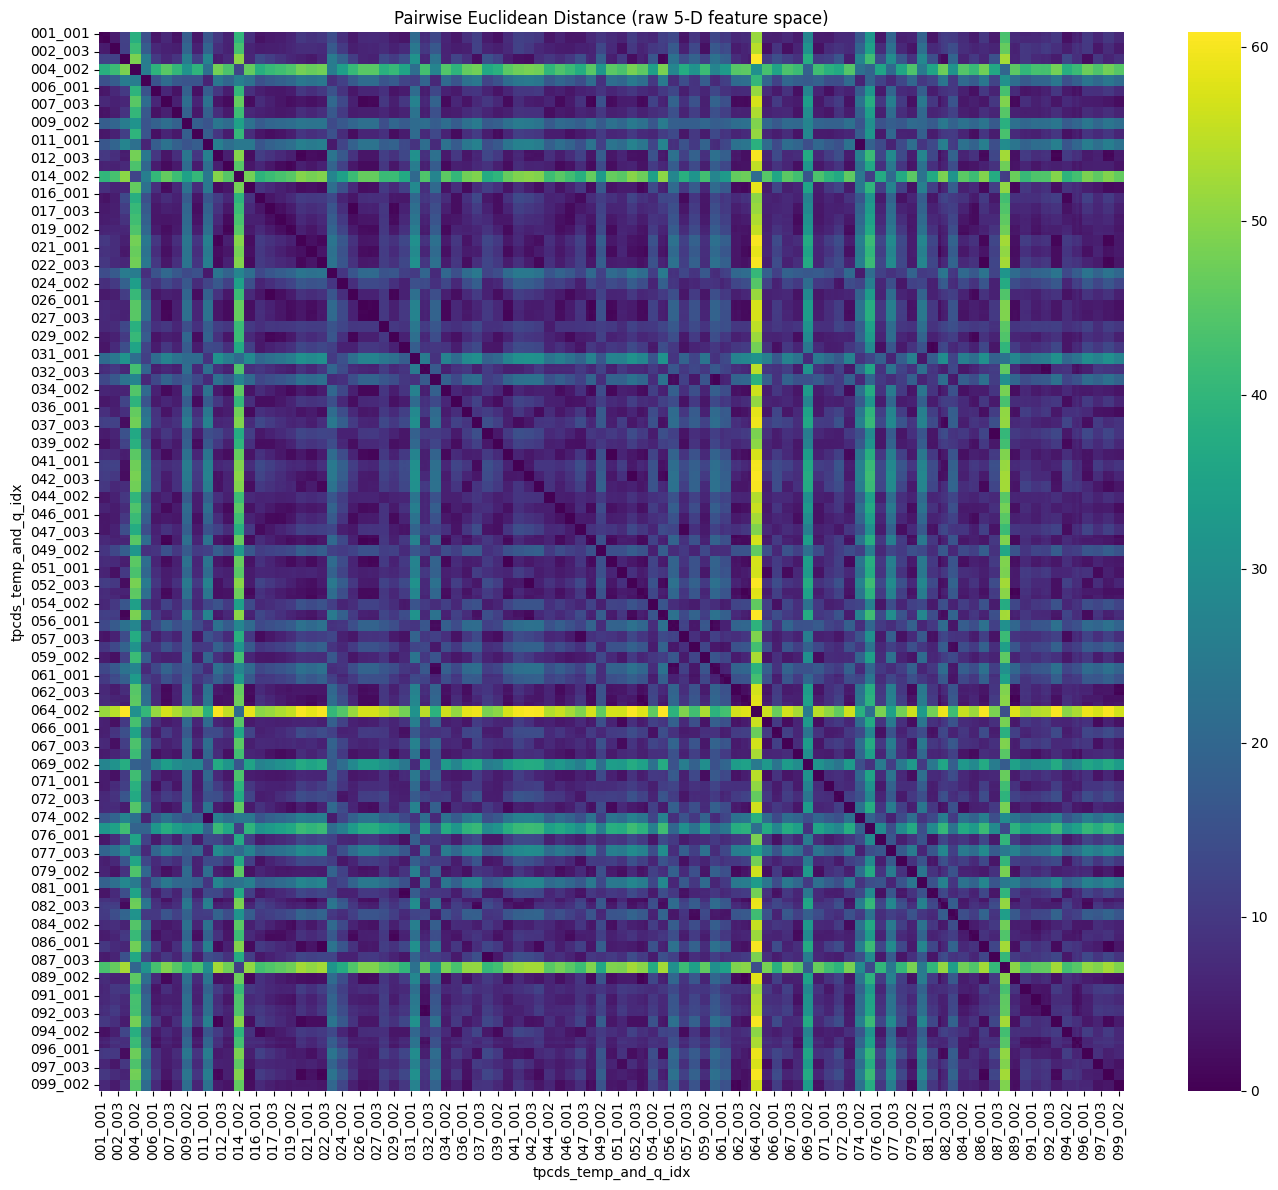

In [6]:
# ── Pairwise Euclidean-distance heatmap (raw feature space) ──

from scipy.spatial.distance import pdist, squareform

cols = TpcdsMatchingFeaturizer.FEATURE_NAMES
dist_matrix = squareform(pdist(feature_df[cols].values, metric="euclidean"))
dist_df = pd.DataFrame(
    dist_matrix,
    index=feature_df.index,
    columns=feature_df.index,
)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(dist_df, cmap="viridis", ax=ax)
ax.set_title("Pairwise Euclidean Distance (raw 5-D feature space)")
plt.tight_layout()
plt.savefig("pairwise_distance_heatmap.svg", dpi=150)
plt.show()

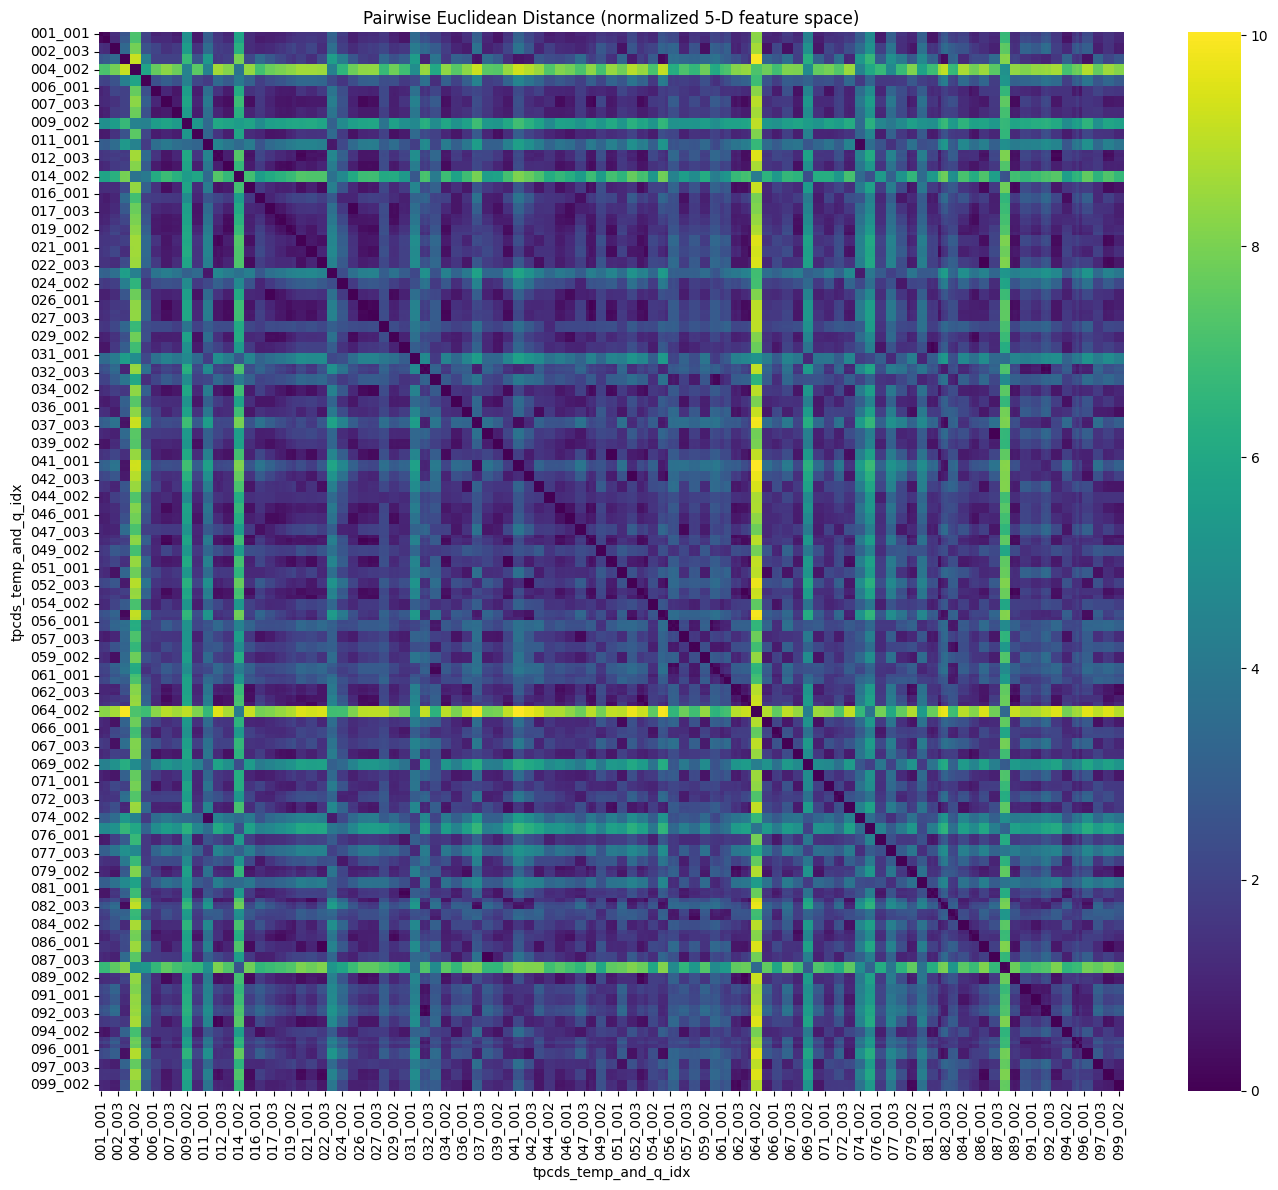

In [7]:
# ── Pairwise Euclidean-distance heatmap (normalized feature space) ──

from scipy.spatial.distance import pdist, squareform

cols = TpcdsMatchingFeaturizer.FEATURE_NAMES
dist_matrix = squareform(pdist(normalized_feature_df[cols].values, metric="euclidean"))
dist_df = pd.DataFrame(
    dist_matrix,
    index=normalized_feature_df.index,
    columns=normalized_feature_df.index,
)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(dist_df, cmap="viridis", ax=ax)
ax.set_title("Pairwise Euclidean Distance (normalized 5-D feature space)")
plt.tight_layout()
plt.savefig("pairwise_distance_heatmap_normalized.svg", dpi=150)
plt.show()

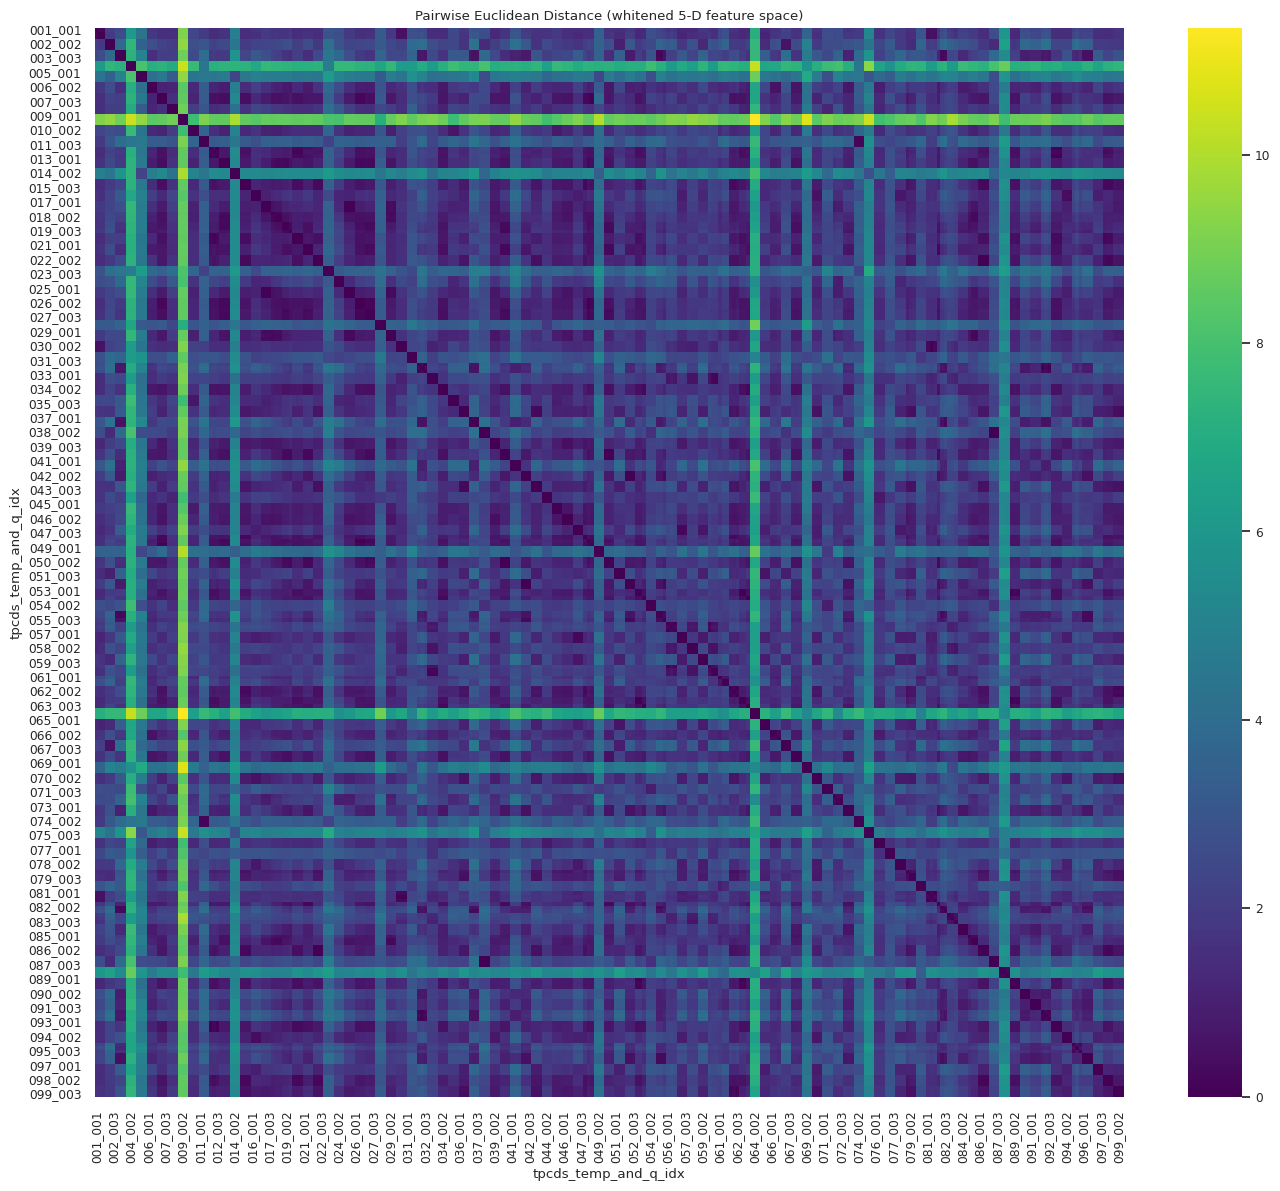

In [17]:
# ── Pairwise Euclidean-distance heatmap (whitened feature space) ──

from scipy.spatial.distance import pdist, squareform

cols = TpcdsMatchingFeaturizer.FEATURE_NAMES
dist_matrix = squareform(pdist(whitened_feature_df[cols].values, metric="euclidean"))
dist_df = pd.DataFrame(
    dist_matrix,
    index=whitened_feature_df.index,
    columns=whitened_feature_df.index,
)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(dist_df, cmap="viridis", ax=ax)
ax.set_title("Pairwise Euclidean Distance (whitened 5-D feature space)")
plt.tight_layout()
plt.savefig("pairwise_distance_heatmap_whitened.svg", dpi=150)
plt.show()

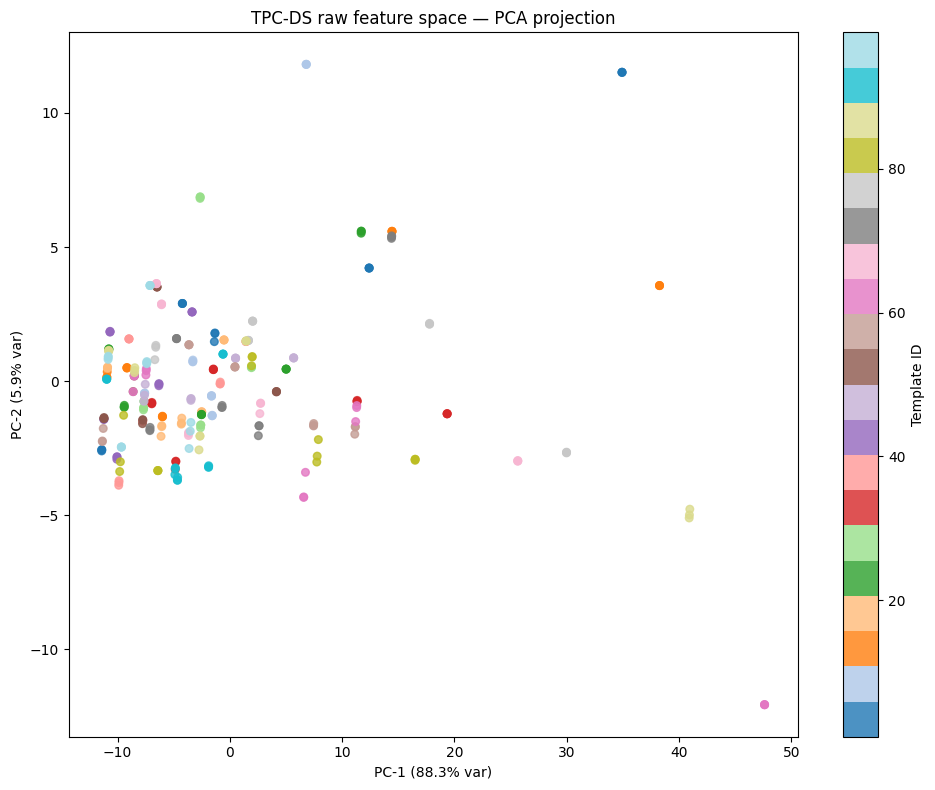

In [8]:
# ── PCA scatter (first 2 components) ──

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(feature_df[cols].values)

# Extract template id for colouring
template_ids = feature_df.index.to_series().str.split("_").str[0].astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=template_ids.values,
    cmap="tab20",
    s=30,
    alpha=0.8,
)
ax.set_xlabel(f"PC-1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC-2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("TPC-DS raw feature space — PCA projection")
plt.colorbar(scatter, ax=ax, label="Template ID")
plt.tight_layout()
plt.savefig("pca_scatter.svg", dpi=150)
plt.show()

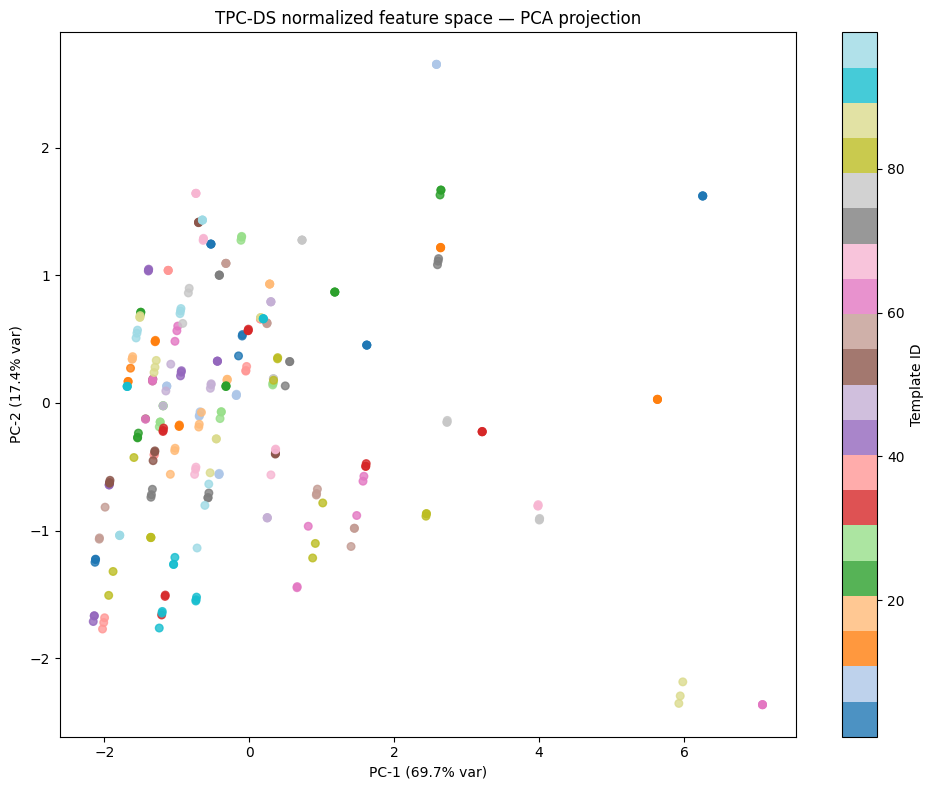

In [9]:
# ── PCA scatter (first 2 components) ──

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(normalized_feature_df[cols].values)

# Extract template id for colouring
template_ids = normalized_feature_df.index.to_series().str.split("_").str[0].astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=template_ids.values,
    cmap="tab20",
    s=30,
    alpha=0.8,
)
ax.set_xlabel(f"PC-1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC-2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("TPC-DS normalized feature space — PCA projection")
plt.colorbar(scatter, ax=ax, label="Template ID")
plt.tight_layout()
plt.savefig("pca_scatter_norm.svg", dpi=150)
plt.show()

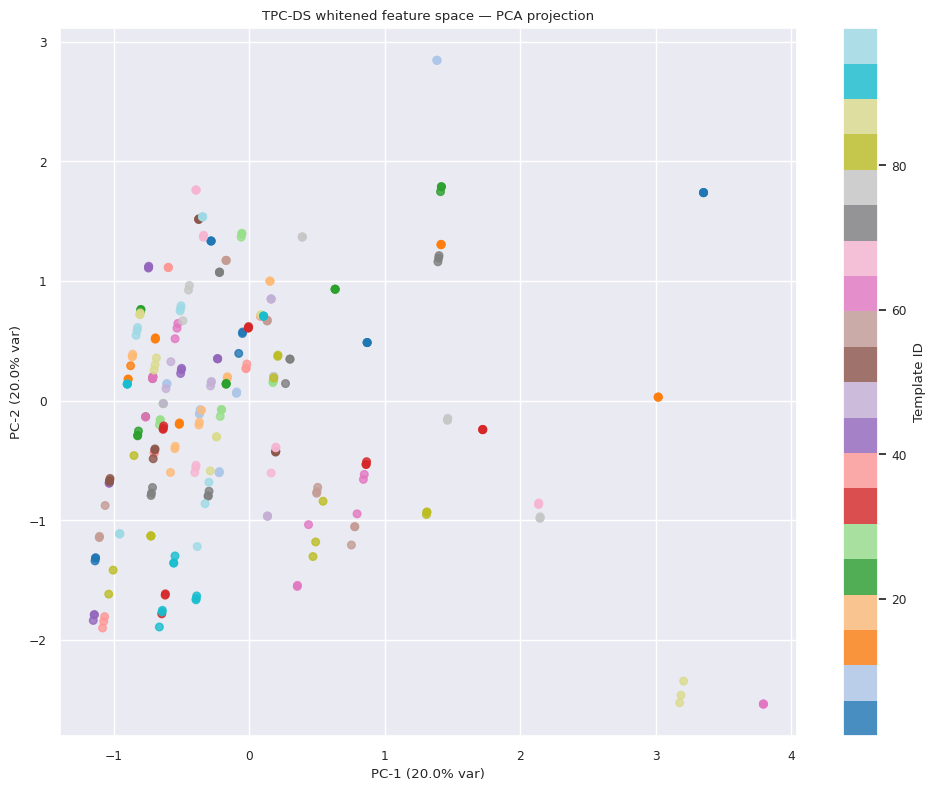

In [18]:
# ── PCA scatter (first 2 components) ──

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(whitened_feature_df[cols].values)

# Extract template id for colouring
template_ids = whitened_feature_df.index.to_series().str.split("_").str[0].astype(int)

fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(
    pca_coords[:, 0],
    pca_coords[:, 1],
    c=template_ids.values,
    cmap="tab20",
    s=30,
    alpha=0.8,
)
ax.set_xlabel(f"PC-1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC-2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("TPC-DS whitened feature space — PCA projection")
plt.colorbar(scatter, ax=ax, label="Template ID")
plt.tight_layout()
plt.savefig("pca_scatter_whitened.svg", dpi=150)
plt.show()

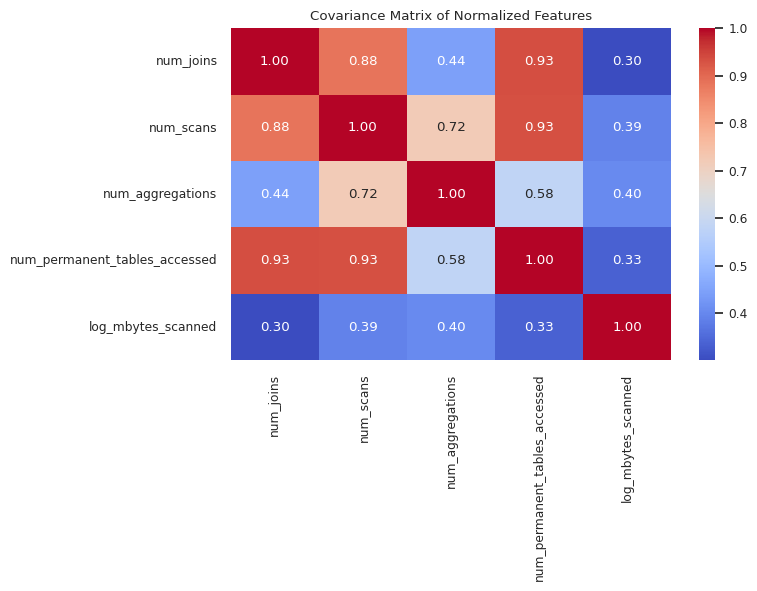

In [14]:
# --- Feature covariance matrix (normalized features) ---
sns.set(font_scale=0.8)
cov_matrix = normalized_feature_df[cols].cov()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Covariance Matrix of Normalized Features")
plt.tight_layout()
plt.savefig("feature_covariance_matrix_normalized.svg", dpi=150)
plt.show()

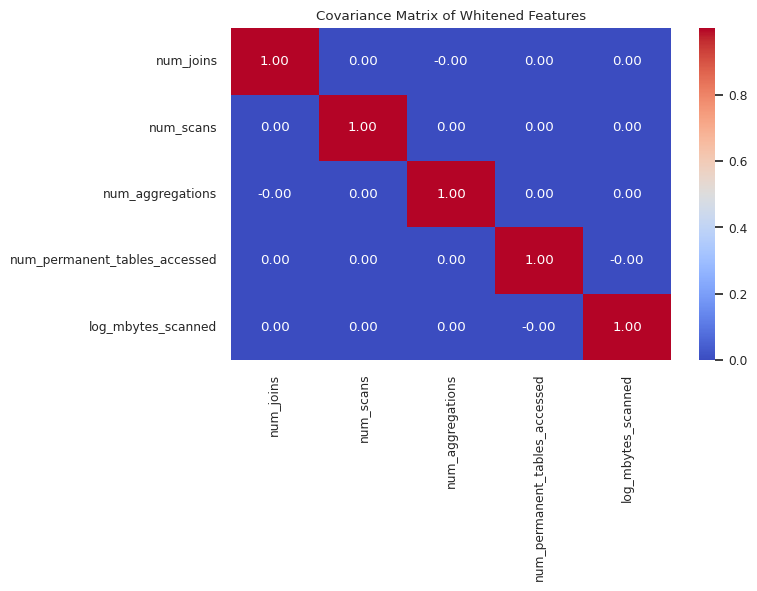

In [19]:
# --- Feature covariance matrix (whitened features) ---
sns.set(font_scale=0.8)
cov_matrix = whitened_feature_df[cols].cov()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cov_matrix, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Covariance Matrix of Whitened Features")
plt.tight_layout()
plt.savefig("feature_covariance_matrix_whitened.svg", dpi=150)
plt.show()

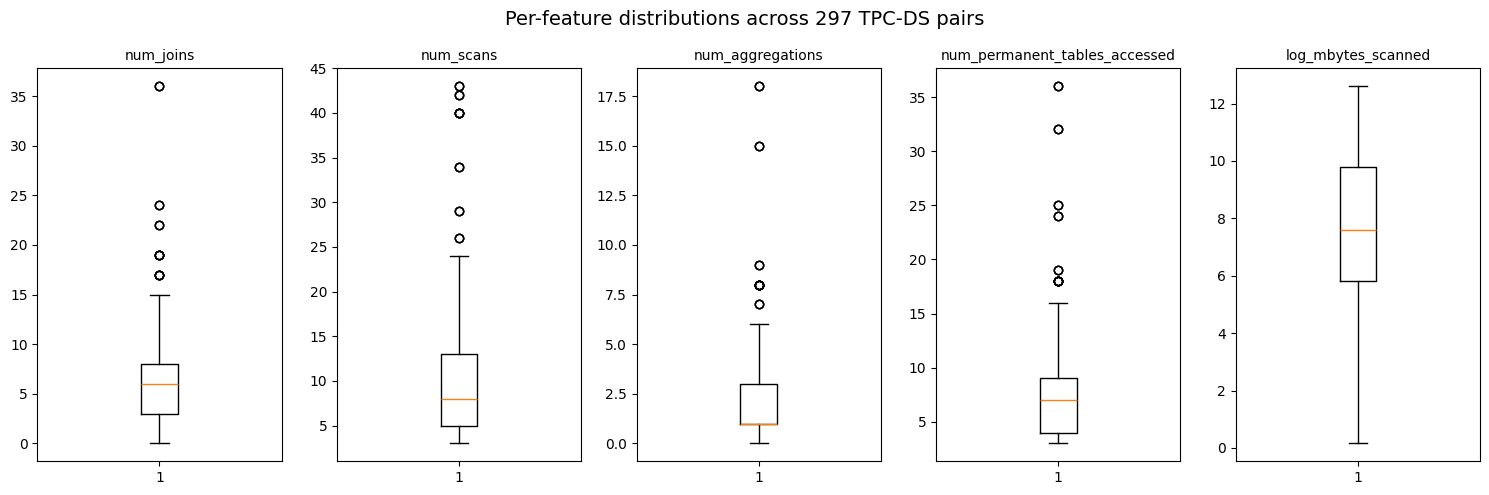

In [10]:
# ── Per-feature distribution box plots ──

fig, axes = plt.subplots(1, len(cols), figsize=(3 * len(cols), 5), sharey=False)
for ax, col in zip(axes, cols):
    ax.boxplot(feature_df[col].dropna())
    ax.set_title(col, fontsize=10)
fig.suptitle("Per-feature distributions across 297 TPC-DS pairs", fontsize=14)
plt.tight_layout()
plt.savefig("feature_distributions.svg", dpi=150)
plt.show()

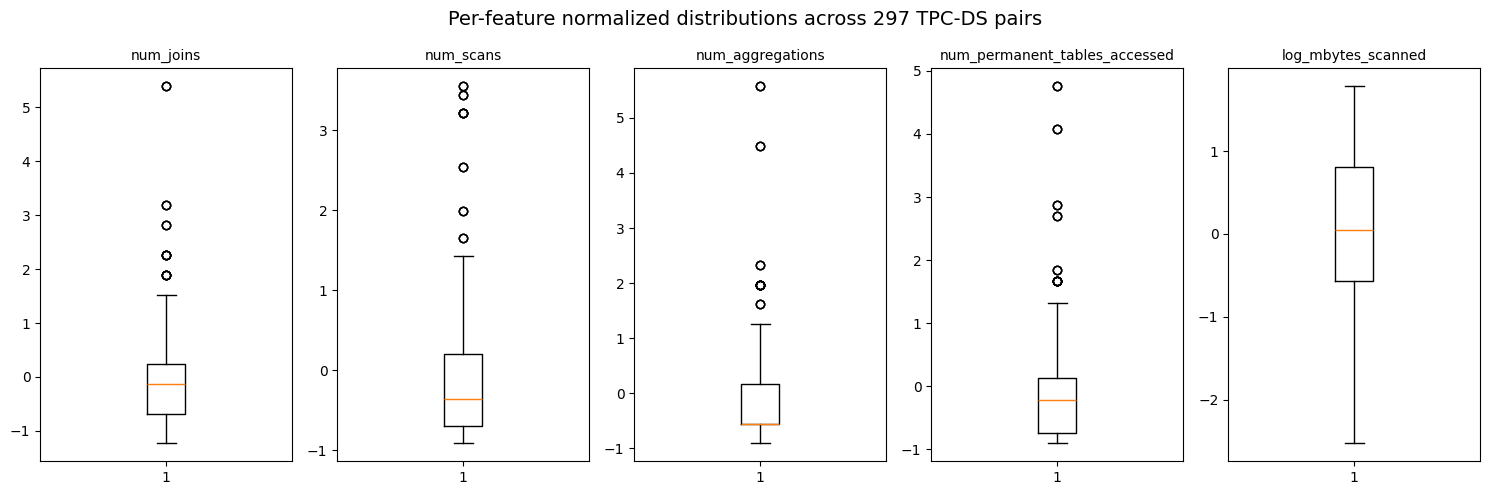

In [11]:
# ── Per-feature normalized distribution box plots ──

fig, axes = plt.subplots(1, len(cols), figsize=(3 * len(cols), 5), sharey=False)
for ax, col in zip(axes, cols):
    ax.boxplot(normalized_feature_df[col].dropna())
    ax.set_title(col, fontsize=10)
fig.suptitle("Per-feature normalized distributions across 297 TPC-DS pairs", fontsize=14)
plt.tight_layout()
plt.savefig("feature_distributions_norm.svg", dpi=150)
plt.show()

In [20]:
# ── Save feature table ──

feature_table_id = featurizer.save(whitened_feature_df, feature_table_id="tpcds_297_pairs_whitened_v2", run_ids=[run_id])
print(f"Feature table saved with id: {feature_table_id}")
print(f"Path: {os.path.join(pu.get_data_path(), 'tpcds_matching_features', str(feature_table_id))}")

Feature table saved with id: tpcds_297_pairs_whitened_v2
Path: /home/markakis/chunkbench/data/tpcds_matching_features/tpcds_297_pairs_whitened_v2
